# **PLANT DATASET**

## 1. Dataset Dowload


In [12]:
import kagglehub

In [13]:
# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

Path to dataset files: /Users/schamazannou/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1


## 2. Data structure exploration

In [14]:
import os

# Voir la structure des dossiers
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level == 1:  # affiche le nombre d'images par classe
        print(f"{'  ' * (level+1)}→ {len(files)} images")

1/
  PlantVillage/
    → 0 images
    Tomato_healthy/
    Potato___Early_blight/
    PlantVillage/
      Tomato_healthy/
      Potato___Early_blight/
      Tomato__Tomato_YellowLeaf__Curl_Virus/
      Tomato_Early_blight/
      Tomato__Target_Spot/
      Potato___Late_blight/
      Tomato_Leaf_Mold/
      Tomato_Spider_mites_Two_spotted_spider_mite/
      Tomato_Septoria_leaf_spot/
      Tomato__Tomato_mosaic_virus/
      Pepper__bell___Bacterial_spot/
      Tomato_Bacterial_spot/
      Tomato_Late_blight/
      Pepper__bell___healthy/
      Potato___healthy/
    Tomato__Tomato_YellowLeaf__Curl_Virus/
    Tomato_Early_blight/
    Tomato__Target_Spot/
    Potato___Late_blight/
    Tomato_Leaf_Mold/
    Tomato_Spider_mites_Two_spotted_spider_mite/
    Tomato_Septoria_leaf_spot/
    Tomato__Tomato_mosaic_virus/
    Pepper__bell___Bacterial_spot/
    Tomato_Bacterial_spot/
    Tomato_Late_blight/
    Pepper__bell___healthy/
    Potato___healthy/


In [15]:
import os

path1 = os.path.join(path, "PlantVillage")          # direct (uppercase)
path2 = os.path.join(path, "plantvillage", "PlantVillage")  # nested (lowercase then uppercase)

print(f"Path 1 — nb classes : {len(os.listdir(path1))}")
print(f"Path 2 — nb classes : {len(os.listdir(path2))}")

# Count images in each
count1 = sum(len(os.listdir(os.path.join(path1, c))) for c in os.listdir(path1) if os.path.isdir(os.path.join(path1, c)))
count2 = sum(len(os.listdir(os.path.join(path2, c))) for c in os.listdir(path2) if os.path.isdir(os.path.join(path2, c)))

print(f"Path 1 — nb images  : {count1}")
print(f"Path 2 — nb images  : {count2}")

Path 1 — nb classes : 16
Path 2 — nb classes : 15
Path 1 — nb images  : 20654
Path 2 — nb images  : 20639


## 3. Dataset exploration

In [16]:
import os

# Le bon chemin vers les images
data_path = os.path.join(path, "plantvillage", "PlantVillage")

# Compter les images par classe et regrouper par plante
results = {}

for class_name in sorted(os.listdir(data_path)):
    class_path = os.path.join(data_path, class_name)
    if os.path.isdir(class_path):
        n_images = len(os.listdir(class_path))

        # Identifier la plante (premier mot avant __)
        plant = class_name.split("_")[0]

        if plant not in results:
            results[plant] = {"total": 0, "classes": []}

        results[plant]["total"] += n_images
        results[plant]["classes"].append((class_name, n_images))

# Afficher le résumé
for plant, data in results.items():
    print(f"\n🌿 {plant.upper()} — {data['total']} images au total")
    print("-" * 50)
    for class_name, count in data["classes"]:
        print(f"  {class_name:<50} : {count} images")


🌿 PEPPER — 2475 images au total
--------------------------------------------------
  Pepper__bell___Bacterial_spot                      : 997 images
  Pepper__bell___healthy                             : 1478 images

🌿 POTATO — 2152 images au total
--------------------------------------------------
  Potato___Early_blight                              : 1000 images
  Potato___Late_blight                               : 1000 images
  Potato___healthy                                   : 152 images

🌿 TOMATO — 16012 images au total
--------------------------------------------------
  Tomato_Bacterial_spot                              : 2127 images
  Tomato_Early_blight                                : 1000 images
  Tomato_Late_blight                                 : 1909 images
  Tomato_Leaf_Mold                                   : 952 images
  Tomato_Septoria_leaf_spot                          : 1771 images
  Tomato_Spider_mites_Two_spotted_spider_mite        : 1676 images
  Tomato__Tar

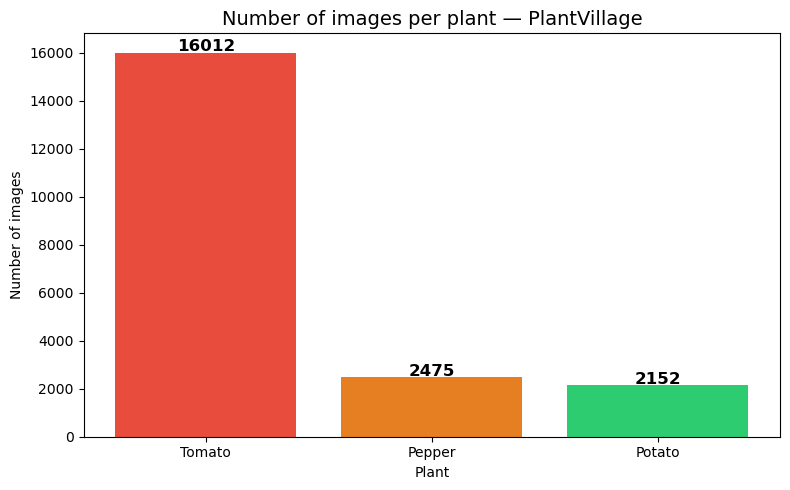


Total: 20639 images

Plant        | Percentage
-------------------------
Tomato       | 77.6%
Pepper       | 12.0%
Potato       | 10.4%


In [18]:
import os
import matplotlib.pyplot as plt

data_path = os.path.join(path, "plantvillage", "PlantVillage")

# Count images per plant
plant_totals = {}
for class_name in os.listdir(data_path):
    class_path = os.path.join(data_path, class_name)
    if os.path.isdir(class_path):
        plant = class_name.split("_")[0]
        n_images = len(os.listdir(class_path))
        plant_totals[plant] = plant_totals.get(plant, 0) + n_images

# Sort by count
plants = sorted(plant_totals, key=plant_totals.get, reverse=True)
counts = [plant_totals[p] for p in plants]
total = sum(counts)
percentages = [f"{100 * float(c) / float(total):.1f}%" for c in counts]

# Histogram with counts on bars
plt.figure(figsize=(8, 5))
bars = plt.bar(plants, counts, color=["#e74c3c", "#e67e22", "#2ecc71"])

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', fontsize=12, fontweight='bold')

plt.title("Number of images per plant — PlantVillage", fontsize=14)
plt.xlabel("Plant")
plt.ylabel("Number of images")
plt.tight_layout()
plt.savefig("distribution.png",       bbox_inches="tight", dpi=150)
plt.show()

# Summary table with percentages
print(f"\nTotal: {total} images\n")
print(f"{'Plant':<12} | {'Percentage'}")
print("-" * 25)
for plant, pct in zip(plants, percentages):
    print(f"{plant:<12} | {pct}")

# Focus on Tomato plants images

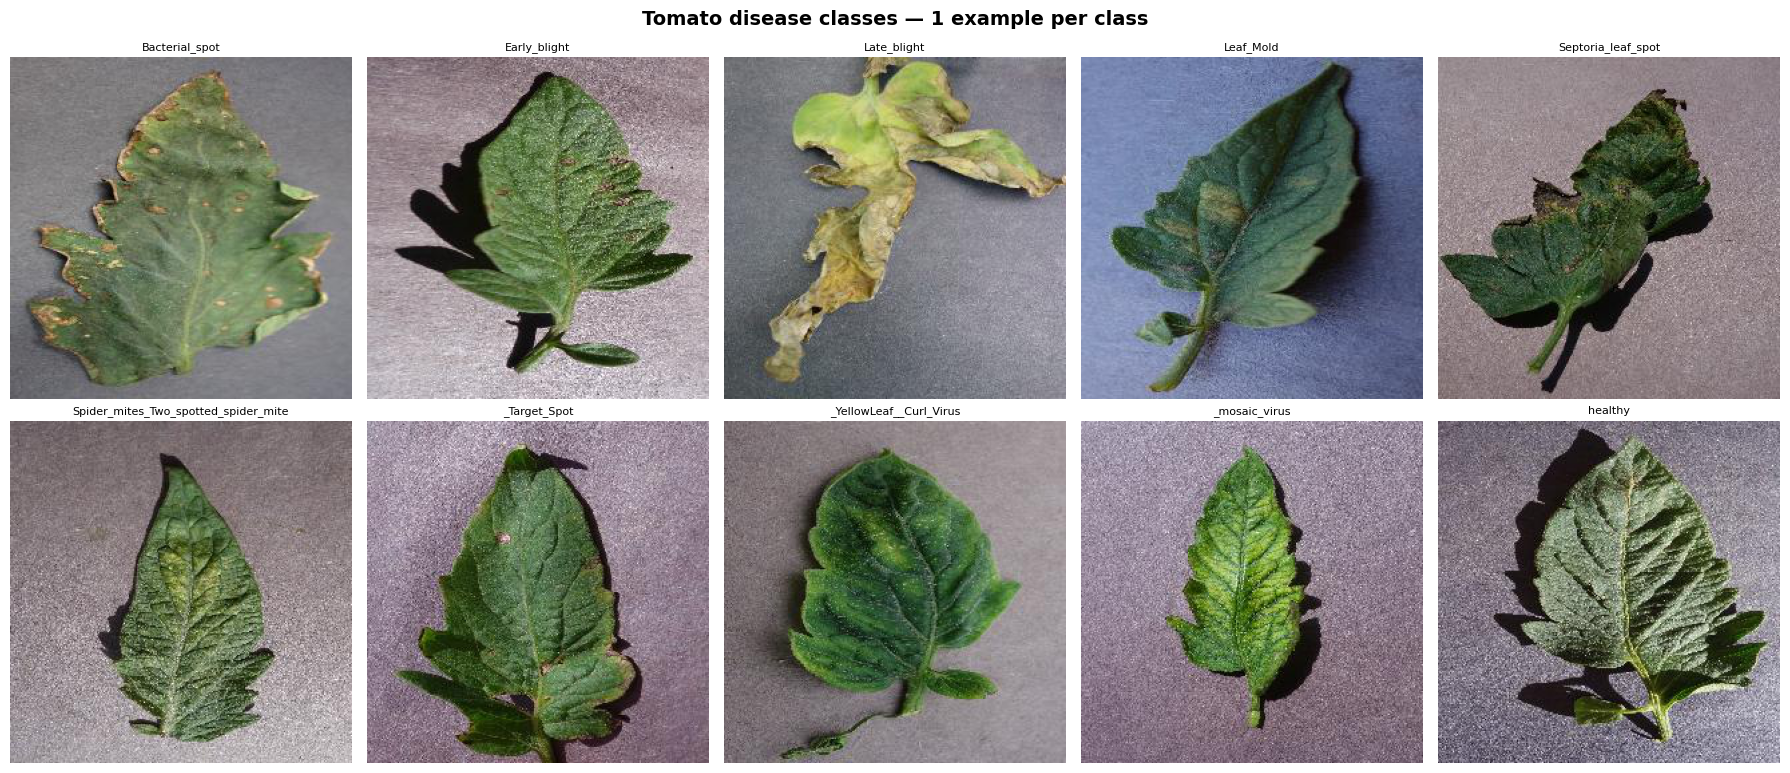


Number of tomato classes: 10
  Tomato_Bacterial_spot                                   : 2127 images
  Tomato_Early_blight                                     : 1000 images
  Tomato_Late_blight                                      : 1909 images
  Tomato_Leaf_Mold                                        : 952 images
  Tomato_Septoria_leaf_spot                               : 1771 images
  Tomato_Spider_mites_Two_spotted_spider_mite             : 1676 images
  Tomato__Target_Spot                                     : 1404 images
  Tomato__Tomato_YellowLeaf__Curl_Virus                   : 3209 images
  Tomato__Tomato_mosaic_virus                             : 373 images
  Tomato_healthy                                          : 1591 images


In [19]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Keep only Tomato classes
tomato_classes = [c for c in os.listdir(data_path) if c.startswith("Tomato")]
tomato_classes = sorted(tomato_classes)

# Display 1 example image per class
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, class_name in enumerate(tomato_classes):
    class_path = os.path.join(data_path, class_name)
    img_file = os.listdir(class_path)[0]  # first image
    img = mpimg.imread(os.path.join(class_path, img_file))

    axes[i].imshow(img)
    axes[i].set_title(class_name.replace("Tomato_", "").replace("Tomato__", ""), fontsize=8)
    axes[i].axis("off")

plt.suptitle("Tomato disease classes — 1 example per class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("tomato_disease.png",       bbox_inches="tight", dpi=150)
plt.show()

print(f"\nNumber of tomato classes: {len(tomato_classes)}")
for c in tomato_classes:
    n = len(os.listdir(os.path.join(data_path, c)))
    print(f"  {c:<55} : {n} images")

# Tomato Classes => Full Description Analysis

TypeError: unsupported format string passed to sage.rings.rational.Rational.__format__

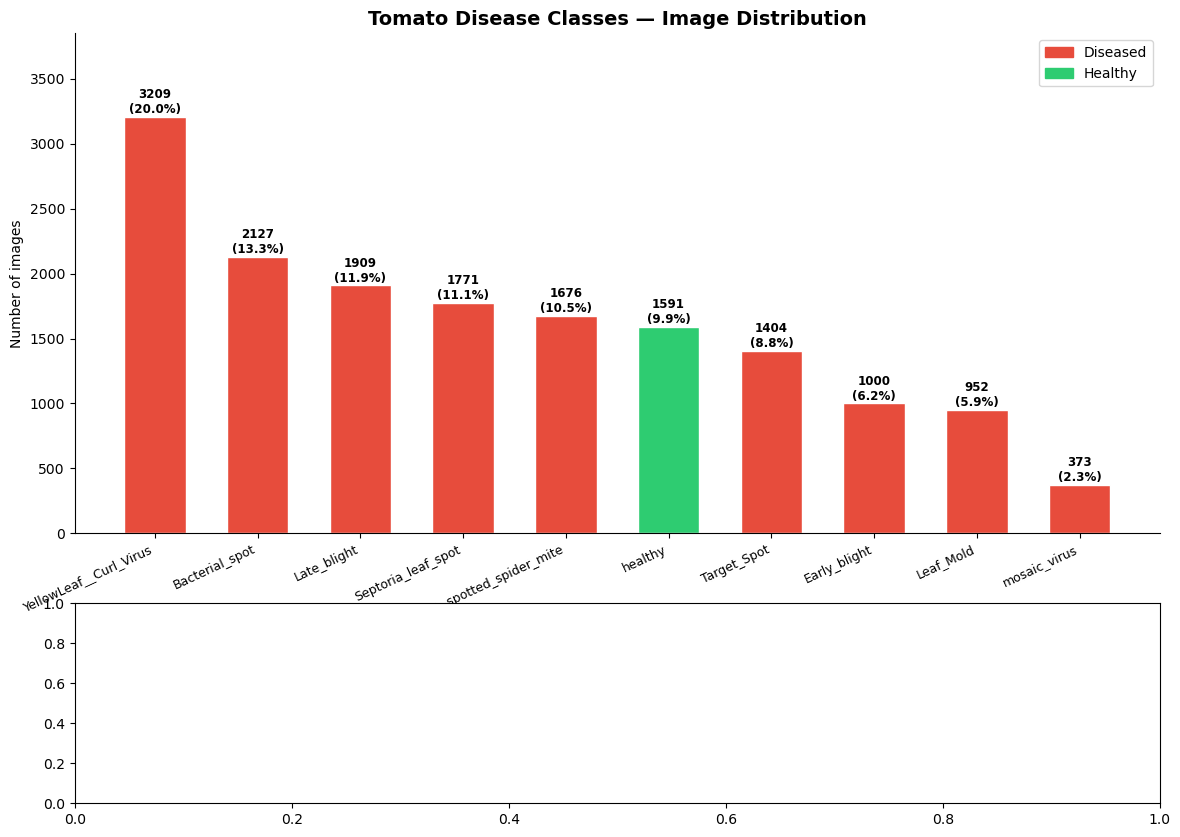

In [21]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

data_path = os.path.join(path, "plantvillage", "PlantVillage")

# Get tomato classes and counts
tomato_classes = {c: len(os.listdir(os.path.join(data_path, c)))
                  for c in os.listdir(data_path) if c.startswith("Tomato")}

# Sort by count descending
tomato_classes = dict(sorted(tomato_classes.items(), key=lambda x: x[1], reverse=True))

total = sum(tomato_classes.values())
labels = [c.replace("Tomato__", "").replace("Tomato_", "") for c in tomato_classes]
counts = list(tomato_classes.values())
percentages = [100 * c / total for c in counts]

# --- Color: highlight healthy in green, rest in red shades ---
colors = ["#2ecc71" if "healthy" in l else "#e74c3c" for l in labels]

fig, (ax_bar, ax_table) = plt.subplots(2, 1, figsize=(14, 10),
                                        gridspec_kw={"height_ratios": [3, 1.2]})

# --- Bar chart ---
x = np.arange(len(labels))
bars = ax_bar.bar(x, counts, color=colors, edgecolor="white", width=0.6)

for bar, count, pct in zip(bars, counts, percentages):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f"{count}\n({float(pct):.1f}%)", ha='center', fontsize=8.5, fontweight='bold')

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
ax_bar.set_ylabel("Number of images")
ax_bar.set_title("Tomato Disease Classes — Image Distribution", fontsize=14, fontweight='bold')
ax_bar.set_ylim(0, max(counts) * 1.2)
ax_bar.spines[["top", "right"]].set_visible(False)

legend = [mpatches.Patch(color="#e74c3c", label="Diseased"),
          mpatches.Patch(color="#2ecc71", label="Healthy")]
ax_bar.legend(handles=legend, loc="upper right")

# --- Table below ---
table_data = [[l, str(c), f"{p:.1f}%"] for l, c, p in zip(labels, counts, percentages)]
table_data.insert(0, ["Class", "Images", "Percentage"])

table = ax_table.table(cellText=table_data[1:],
                       colLabels=table_data[0],
                       cellLoc='center', loc='center')

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

# Style header
for j in range(3):
    table[0, j].set_facecolor("#2c3e50")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Style rows
for i in range(1, len(table_data)):
    row_color = "#f9f9f9" if i % 2 == 0 else "white"
    for j in range(3):
        table[i, j].set_facecolor(row_color)

ax_table.axis("off")

plt.suptitle(f"PlantVillage — Tomato | Total: {total} images | 10 classes",
             fontsize=11, color="gray", y=0.98)
plt.tight_layout()
plt.savefig("tomato_distribution.png",    bbox_inches="tight", dpi=150)
plt.show()

## 4. Data preparation


In [17]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Dataset
import torch

# --- Two separate transforms ---
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# --- Load full dataset (without transform — applied later) ---
full_dataset = datasets.ImageFolder(root=data_path)

# --- Keep only Tomato classes and remap labels 0 to 9 ---
tomato_only = [(name, idx) for name, idx in full_dataset.class_to_idx.items()
               if "Tomato" in name]
tomato_class_indices = {idx: i for i, (name, idx) in enumerate(tomato_only)}

# --- Custom dataset with per-split transform ---
class TomatoDataset(Dataset):
    def __init__(self, full_dataset, class_map, transform):
        self.samples   = [(path, class_map[label])
                          for path, label in full_dataset.samples
                          if label in class_map]
        self.transform = transform
        self.loader    = full_dataset.loader

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = self.loader(path)
        image = self.transform(image)
        return image, label

# --- Build train and test datasets with their own transform ---
train_size = int(0.8 * len(tomato_class_indices) * sum(
    1 for _, label in full_dataset.samples if label in tomato_class_indices))

all_samples = [(path, tomato_class_indices[label])
               for path, label in full_dataset.samples
               if label in tomato_class_indices]

total      = len(all_samples)
train_size = int(0.8 * total)
test_size  = total - train_size

# Shuffle and split indices
torch.manual_seed(42)
indices      = torch.randperm(total).tolist()
train_idx    = indices[:train_size]
test_idx     = indices[train_size:]

class SplitDataset(Dataset):
    def __init__(self, samples, indices, transform):
        self.samples   = [samples[i] for i in indices]
        self.transform = transform
        self.loader    = full_dataset.loader

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = self.loader(path)
        image = self.transform(image)
        return image, label

train_set = SplitDataset(all_samples, train_idx, train_transform)
test_set  = SplitDataset(all_samples, test_idx,  test_transform)

# --- DataLoaders ---
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False)

# --- Summary ---
print(f"Total Tomato images : {total}")
print(f"Training set        : {train_size} images (with augmentation)")
print(f"Test set            : {test_size} images (no augmentation)")
print(f"Number of classes    : {len(set(full_dataset.targets))}")
print(f"Batch size           : 32")
print(f"\nClass mapping (new label → class name):")
for name, idx in full_dataset.class_to_idx.items():
    if idx in tomato_class_indices:
        print(f"  {tomato_class_indices[idx]} → {name}")

Total Tomato images : 16011
Training set        : 12808 images (with augmentation)
Test set            : 3203 images (no augmentation)
Number of classes    : 15
Batch size           : 32

Class mapping (new label → class name):
  0 → Tomato_Bacterial_spot
  1 → Tomato_Early_blight
  2 → Tomato_Late_blight
  3 → Tomato_Leaf_Mold
  4 → Tomato_Septoria_leaf_spot
  5 → Tomato_Spider_mites_Two_spotted_spider_mite
  6 → Tomato__Target_Spot
  7 → Tomato__Tomato_YellowLeaf__Curl_Virus
  8 → Tomato__Tomato_mosaic_virus
  9 → Tomato_healthy


## 5. Model Architecture => CNN from Scratch

Topic : Model Architecture — CNN from Scratch
Avant de donner le code, expliquons ce qu'est un CNN et pourquoi on l'utilise.

Pourquoi un CNN pour des images ?
Un réseau classique (fully connected) ne voit qu'une liste de chiffres — il perd la structure spatiale de l'image. Un CNN lui, détecte des patterns locaux (bords, textures, taches) — parfait pour des maladies sur des feuilles.

Notre architecture


```
Image [3, 128, 128]
      ↓
Conv2d + ReLU + MaxPool     → détecte les bords et textures simples
      ↓
Conv2d + ReLU + MaxPool     → détecte des patterns plus complexes
      ↓
Conv2d + ReLU + MaxPool     → détecte des formes de maladies
      ↓
Flatten                     → transforme en vecteur 1D
      ↓
Linear + ReLU               → couche cachée
      ↓
Linear                      → 10 sorties (une par classe)
```



In [18]:
import torch
import torch.nn as nn

class TomatoCNN(nn.Module):

    def __init__(self, num_classes=10):
        super(TomatoCNN, self).__init__()

        # --- Feature extraction (3 conv blocks) ---
        self.features = nn.Sequential(

            # Block 1: detect edges and basic textures
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 128x128 → 64x64

            # Block 2: detect more complex patterns
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 64x64 → 32x32

            # Block 3: detect disease-specific shapes
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),   # 32x32 → 16x16
        )

        # --- Classification (fully connected layers) ---
        self.classifier = nn.Sequential(
            nn.Flatten(),                        # [128, 16, 16] → [32768]
            nn.Linear(128 * 16 * 16, 256),       # hidden layer
            nn.ReLU(),
            nn.Dropout(0.4),                     # Randomly deactivate 40% of neurones
            nn.Linear(256, num_classes)          # output: 10 classes
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# --- Verify the model ---
model = TomatoCNN(num_classes=10)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# Test with a fake image batch
dummy = torch.zeros(1, 3, 128, 128)   # 1 image, 3 channels, 128x128
output = model(dummy)
print(f"Input shape  : {dummy.shape}")
print(f"Output shape : {output.shape}  ← should be [1, 10]")

TomatoCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

Total parameters: 8,484,682
Input shape  : torch.Size([1, 3, 128, 128])
Output shape : torch.Size([1, 10])  ← should be [1, 10]


# **Comprendre le CNN — Analogie concrète**
Imagine que tu es un médecin qui regarde une feuille de tomate malade. Tu ne regardes pas toute la feuille d'un coup — tu zoomes progressivement :

D'abord tu repères les bords et contours de la feuille
Ensuite tu identifies des textures anormales (taches jaunes, brunes)
Enfin tu reconnais la forme spécifique d'une maladie
C'est exactement ce que fait notre CNN — 3 niveaux de lecture.

## **Ce qui se passe concrètement sur une image**



```
Image originale : photo d'une feuille de tomate [3 canaux, 128×128 pixels]
       │
       ▼  BLOCK 1 — "Je cherche des bords et couleurs de base"
   Conv2d (32 filtres)  →  32 cartes de features [32, 128, 128]
   ReLU                 →  je garde uniquement ce qui est utile
   MaxPool              →  je résume → [32, 64, 64]
       │
       ▼  BLOCK 2 — "Je cherche des textures et taches"
   Conv2d (64 filtres)  →  [64, 64, 64]
   ReLU
   MaxPool              →  [64, 32, 32]
       │
       ▼  BLOCK 3 — "Je cherche des formes de maladies"
   Conv2d (128 filtres) →  [128, 32, 32]
   ReLU
   MaxPool              →  [128, 16, 16]
       │
       ▼  FLATTEN — "Je transforme tout en une liste de chiffres"
   [128 × 16 × 16] = 32 768 chiffres
       │
       ▼  COUCHE CACHÉE — "Je combine les indices trouvés"
   Linear(32768 → 256)
   ReLU
       │
       ▼  COUCHE DE SORTIE — "Je donne mon verdict"
   Linear(256 → 10)   ← un score pour chacune des 10 maladies
```



```
output shape : [1, 10]
```
- 1 → tu as passé 1 image
- 10 → le modèle donne 10 scores, un par classe

Par exemple ::


```
[0.12, 0.03, 0.67, 0.02, 0.05, 0.01, 0.03, 0.02, 0.01, 0.04]
```
La classe avec le score le plus élevé (ici position 2) = la maladie prédite.





## 6. Training Loop


In [19]:
import torch
import torch.nn as nn

# --- Setup ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model     = TomatoCNN(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()           # loss function for multi-class
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Training loop ---
epochs = 10
history_pytorch = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(epochs):

    # ── TRAINING PHASE ──────────────────────────────────────
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # 1. Forward pass
        outputs = model(images)

        # 2. Compute loss
        loss = criterion(outputs, labels)

        # 3. Backward pass
        optimizer.zero_grad()
        loss.backward()

        # 4. Update weights
        optimizer.step()

        # Track stats
        total_loss += loss.item()
        predicted   = outputs.argmax(dim=1)
        correct    += (predicted == labels).sum().item()
        total      += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = 100 * correct / total

    # ── EVALUATION PHASE ────────────────────────────────────
    model.eval()
    correct = 0
    total   = 0
    total_test_loss = 0

    with torch.no_grad():   # no gradient needed for evaluation
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs   = model(images)
            total_test_loss += criterion(outputs, labels).item()
            predicted = outputs.argmax(dim=1)
            correct  += (predicted == labels).sum().item()
            total    += labels.size(0)

    test_loss = total_test_loss / len(test_loader)
    test_acc = correct / total  # between 0 and 1

    # Save history
    history_pytorch["train_loss"].append(train_loss)
    history_pytorch["test_loss"].append(test_loss)
    history_pytorch["train_acc"].append(train_acc / 100)  # convertir en 0-1
    history_pytorch["test_acc"].append(test_acc)

    print(f"Epoch [{epoch+1:02d}/{epochs}] | Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}% | Test Acc: {test_acc*100:.1f}%")

Using device: cuda
Epoch [01/10] | Loss: 0.9711 | Train Acc: 66.2% | Test Acc: 82.1%
Epoch [02/10] | Loss: 0.5128 | Train Acc: 82.4% | Test Acc: 86.9%
Epoch [03/10] | Loss: 0.3766 | Train Acc: 87.3% | Test Acc: 91.5%
Epoch [04/10] | Loss: 0.3146 | Train Acc: 89.5% | Test Acc: 90.2%
Epoch [05/10] | Loss: 0.2711 | Train Acc: 91.1% | Test Acc: 93.3%
Epoch [06/10] | Loss: 0.2422 | Train Acc: 92.0% | Test Acc: 92.6%
Epoch [07/10] | Loss: 0.2170 | Train Acc: 92.6% | Test Acc: 94.3%
Epoch [08/10] | Loss: 0.1880 | Train Acc: 93.7% | Test Acc: 95.5%
Epoch [09/10] | Loss: 0.1789 | Train Acc: 93.7% | Test Acc: 96.5%
Epoch [10/10] | Loss: 0.1649 | Train Acc: 94.5% | Test Acc: 96.5%


## 7. Training Curves Visualization

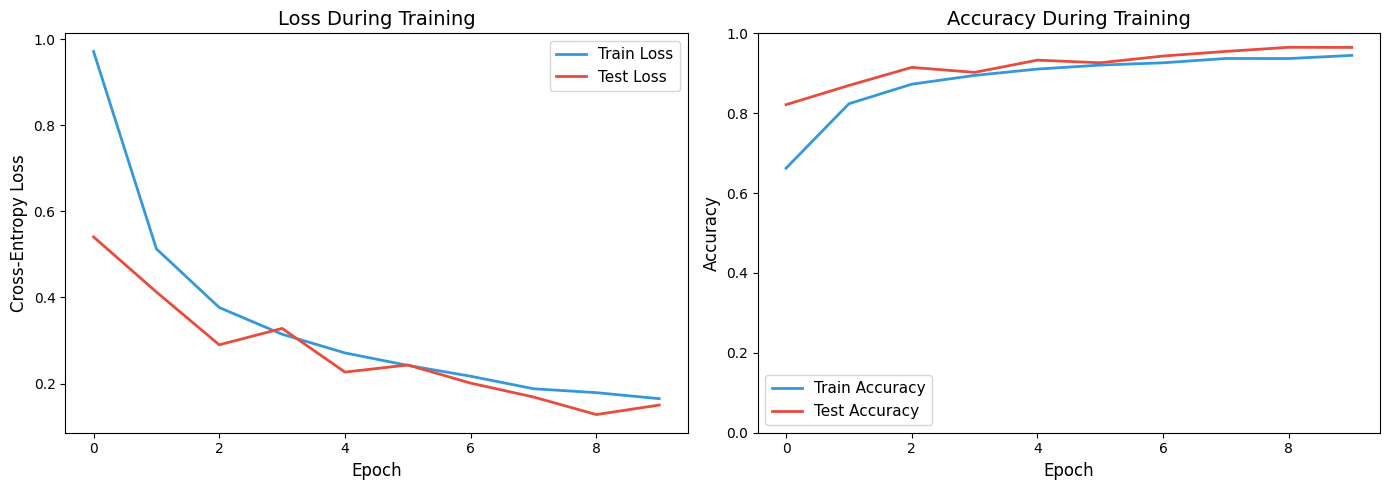

In [ ]:
## 7. Training Curves Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss
ax1 = axes[0]
ax1.plot(history_pytorch['train_loss'], linewidth=2, color='#3498db', label='Train Loss')
ax1.plot(history_pytorch['test_loss'], linewidth=2, color='#e74c3c', label='Test Loss')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax1.set_title('Loss During Training', fontsize=14)
ax1.legend(fontsize=11)

# Plot 2: Accuracy
ax2 = axes[1]
ax2.plot(history_pytorch['train_acc'], linewidth=2, color='#3498db', label='Train Accuracy')
ax2.plot(history_pytorch['test_acc'], linewidth=2, color='#e74c3c', label='Test Accuracy')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy During Training', fontsize=14)
ax2.legend(fontsize=11)
ax2.set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig("training_curves.png",    bbox_inches="tight", dpi=150)
plt.show()

## 8. Model Evaluation - Confusion Matrix


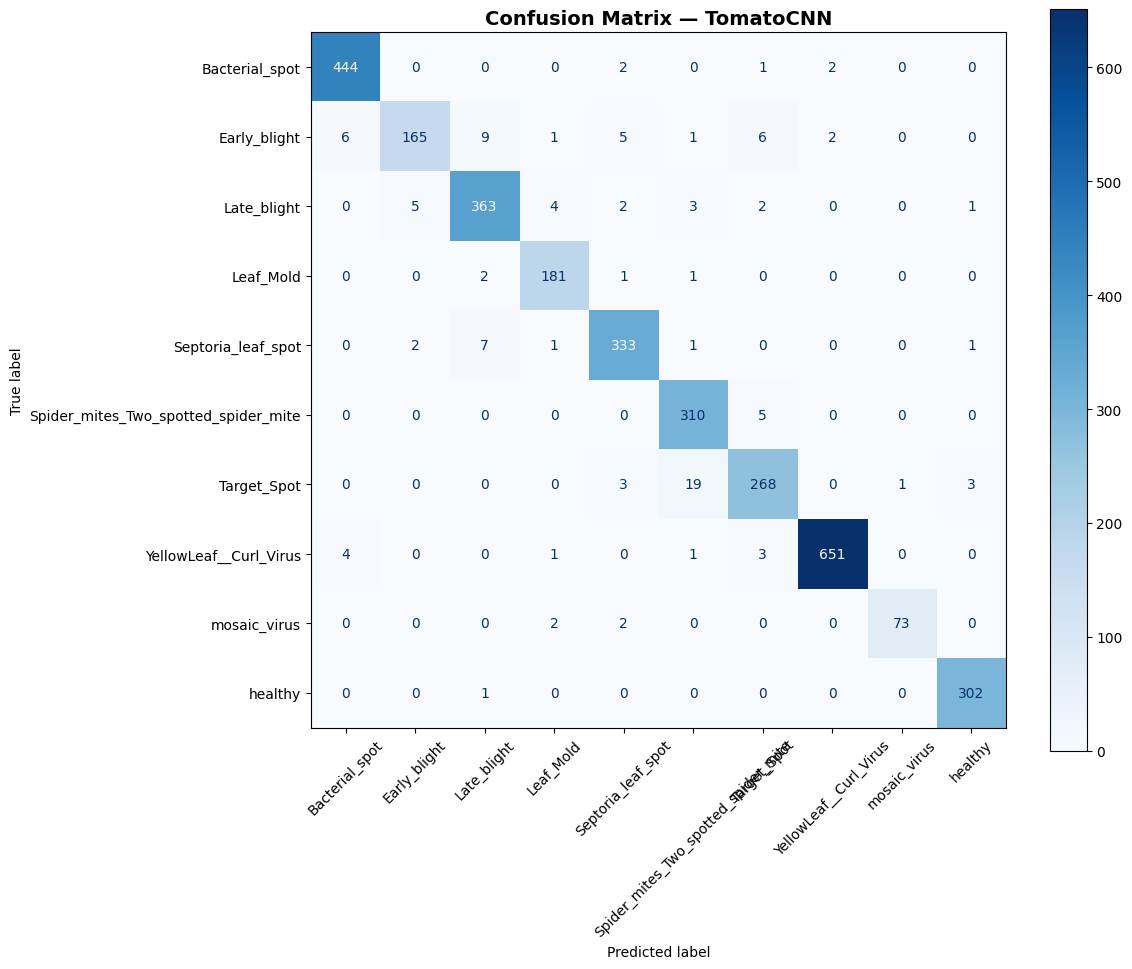


Per-class accuracy:
---------------------------------------------
  Bacterial_spot                           : 98.9%
  Early_blight                             : 84.6%
  Late_blight                              : 95.5%
  Leaf_Mold                                : 97.8%
  Septoria_leaf_spot                       : 96.5%
  Spider_mites_Two_spotted_spider_mite     : 98.4%
  Target_Spot                              : 91.2%
  YellowLeaf__Curl_Virus                   : 98.6%
  mosaic_virus                             : 94.8%
  healthy                                  : 99.7%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Get all predictions on test set ---
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# --- Class names (short version) ---
class_names = [name.replace("Tomato__", "").replace("Tomato_", "")
               for name, _ in sorted(tomato_only, key=lambda x: x[1])]

# --- Confusion matrix ---
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45, cmap="Blues")
ax.set_title("Confusion Matrix — TomatoCNN", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png",   bbox_inches="tight", dpi=150)
plt.show()

# --- Per-class accuracy ---
print("\nPer-class accuracy:")
print("-" * 45)
for i, name in enumerate(class_names):
    correct = cm[i, i]
    total   = cm[i].sum()
    print(f"  {name:<40} : {100*correct/total:.1f}%")

### Classification Report => F1 Score & More

In [22]:
from sklearn.metrics import classification_report

# --- Full classification report ---
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=3
)
print("Classification Report")
print("=" * 70)
print(report)

Classification Report
                                      precision    recall  f1-score   support

                      Bacterial_spot      0.978     0.989     0.983       449
                        Early_blight      0.959     0.846     0.899       195
                         Late_blight      0.950     0.955     0.953       380
                           Leaf_Mold      0.953     0.978     0.965       185
                  Septoria_leaf_spot      0.957     0.965     0.961       345
Spider_mites_Two_spotted_spider_mite      0.923     0.984     0.952       315
                         Target_Spot      0.940     0.912     0.926       294
              YellowLeaf__Curl_Virus      0.994     0.986     0.990       660
                        mosaic_virus      0.986     0.948     0.967        77
                             healthy      0.984     0.997     0.990       303

                            accuracy                          0.965      3203
                           macro avg    

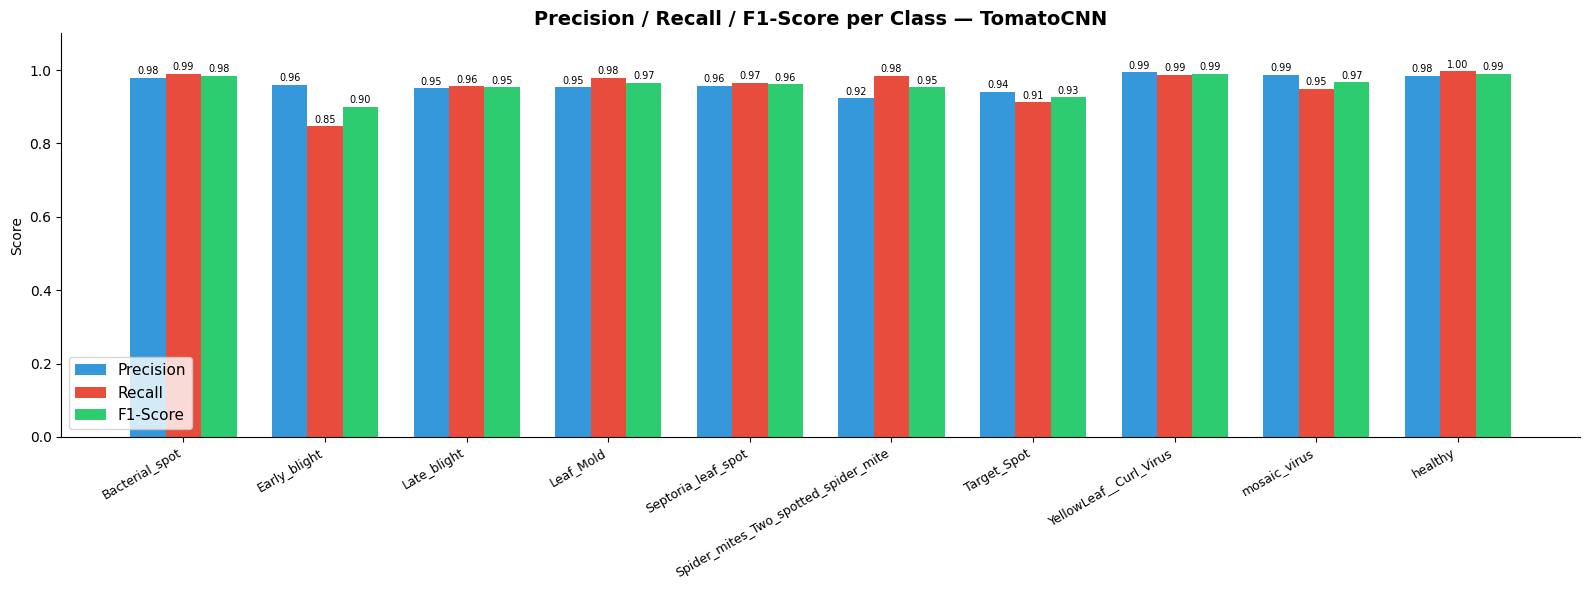

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# --- Compute scores ---
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, average=None
)

x      = np.arange(len(class_names))
width  = 0.25

fig, ax = plt.subplots(figsize=(16, 6))

bars1 = ax.bar(x - width, precision, width, label="Precision", color="#3498db")
bars2 = ax.bar(x,          recall,    width, label="Recall",    color="#e74c3c")
bars3 = ax.bar(x + width,  f1,        width, label="F1-Score",  color="#2ecc71")

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_title("Precision / Recall / F1-Score per Class — TomatoCNN", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.spines[["top", "right"]].set_visible(False)

# Add value labels on top of each bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha='center', fontsize=7)

plt.tight_layout()
plt.savefig("f1_scores.png", bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
from google.colab import files
files.download("distribution.png")
files.download("tomato_disease.png")
files.download("tomato_distribution.png")
files.download("training_curves.png")
files.download("confusion_matrix.png")
files.download("f1_scores.png")

## 9. Model Saving


In [24]:
import os
from google.colab import files

# --- Save model weights ---
torch.save(model.state_dict(), "tomato_cnn.pth")

# --- Save class mapping (needed for the Streamlit app) ---
import json

class_mapping = {str(i): name for i, (name, _) in enumerate(sorted(tomato_only, key=lambda x: x[1]))}

with open("class_mapping.json", "w") as f:
    json.dump(class_mapping, f, indent=2)

print("Files saved:")
print("  tomato_cnn.pth     ← model weights")
print("  class_mapping.json ← class names")
print(f"\nModel size: {os.path.getsize('tomato_cnn.pth') / 1024 / 1024:.1f} MB")

# --- Download both files to your PC ---
files.download("tomato_cnn.pth")
files.download("class_mapping.json")

Files saved:
  tomato_cnn.pth     ← model weights
  class_mapping.json ← class names

Model size: 32.4 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>